In [1]:
import numpy as np
import scipy as sp 
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
import qiskit as qk

# import Qiskit libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import StatevectorSimulator, AerSimulator
from qiskit.visualization import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style


# Quantum Hadamard Edge Detection
To implement QHED, our first step is to encode a given image into a quantum state. We use amplitude encoding for this so QuantumCircuit.initialize is a suitable method for encoding our image. However, some pre-processing may be required depending on image size (i.e. downscalling or image batching).

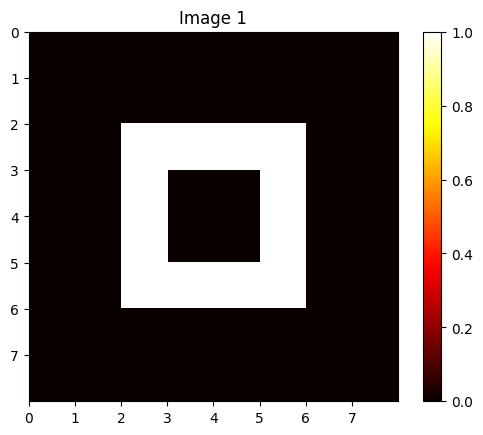

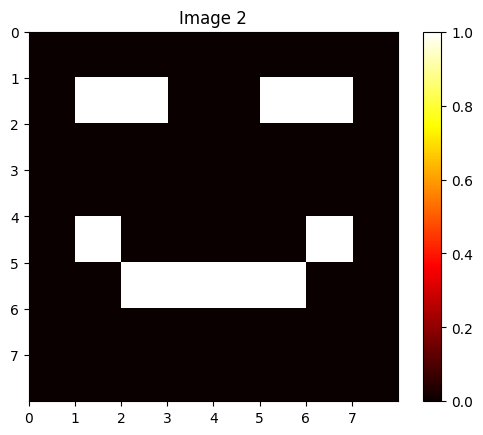

In [4]:
img1 = np.array([[0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 1, 1, 1, 1, 0, 0],
                [0, 0, 1, 0, 0, 1, 0, 0],
                [0, 0, 1, 0, 0, 1, 0, 0],
                [0, 0, 1, 1, 1, 1, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0]])

img2 = np.array([[0, 0, 0, 0, 0, 0, 0, 0],
                [0, 1, 1, 0, 0, 1, 1, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 1, 0, 0, 0, 0, 1, 0],
                [0, 0, 1, 1, 1, 1, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0]])


# plot image function

def plot_image(Image, title):
    plt.title(title)
    plt.xticks(range(Image.shape[0]))
    plt.yticks(range(Image.shape[1]))
    plt.imshow(Image, extent=[  0,Image.shape[0], Image.shape[1],0,], cmap='hot', vmin=0, vmax=1)
    plt.colorbar()
    plt.show()
    
plot_image(img1, 'Image 1')
plot_image(img2, 'Image 2')

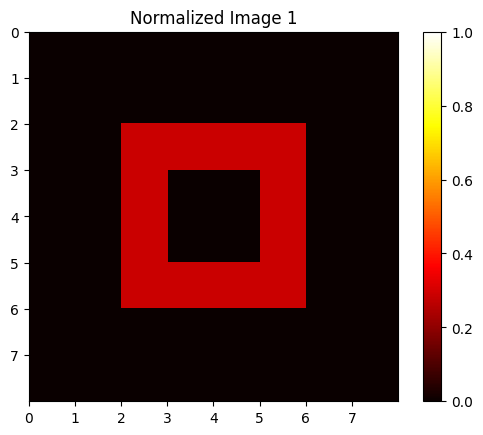

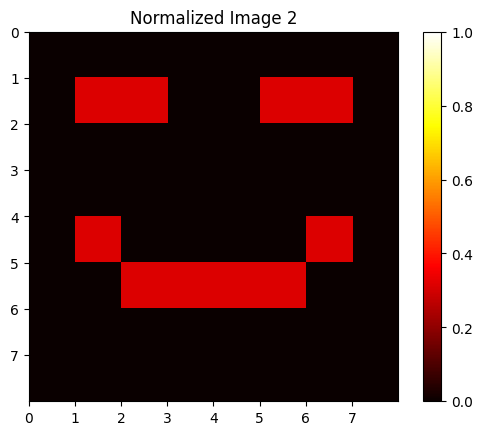

In [9]:
def normalize_image(image):
    shape = image.shape
    norm_image = image.flatten()/np.linalg.norm(image.flatten())
    return norm_image.reshape(shape)

norm_img1 = normalize_image(img1)
norm_img2 = normalize_image(img2)

plot_image(norm_img1, 'Normalized Image 1')
plot_image(norm_img2, 'Normalized Image 2')

class QHED:
    def __init__(self, image):
        self.image = image
        self.norm_image = normalize_image(image)
        self.norm_image_T = self.norm_image.T
        self.hscan = self.norm_image.flatten()
        self.vscan = self.norm_image_T.flatten
        self.n_qubits = np.ceil(np.log2(image.size)).astype(int)

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(128, 128))

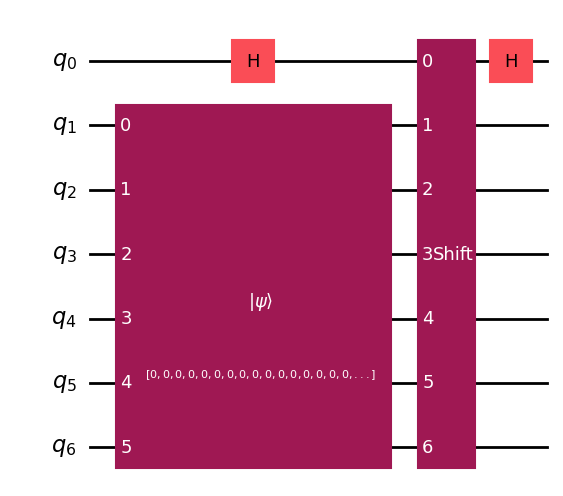

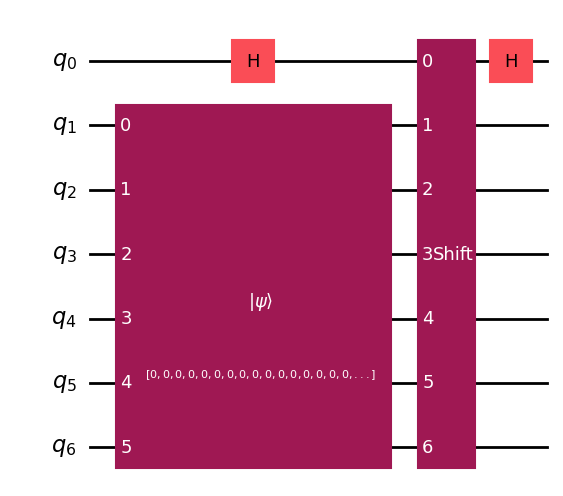

QiskitError: 'Key must be int or a valid binary string.'

In [20]:
class QHED:
    def __init__(self, image, measure=False, display=False, shots=1024):
        self.image = image
        self.norm_image = normalize_image(image)
        self.norm_image_T = self.norm_image.T
        self.hscan = self.norm_image.flatten()
        self.vscan = self.norm_image_T.flatten()

        # +1 ancilla qubit
        self.n_qubits = int(np.ceil(np.log2(image.size))) + 1
        self.shift_matrix = np.roll(np.identity(2**self.n_qubits), 1, axis=1)

        self.measure = measure
        self.display = display
        self.shots = shots

        # simulator must exist before get_results()
        if self.measure:
            self.simulator = AerSimulator()
        else:
            self.simulator = StatevectorSimulator()

        self.circs = [self.horizontal_scan(), self.vertical_scan()]
        self.results = self.get_results()

    def vertical_scan(self):
        qc = QuantumCircuit(self.n_qubits)

        # initialize only data qubits (exclude ancilla q0)
        qc.initialize(self.vscan, range(1, self.n_qubits))
        qc.h(0)
        qc.unitary(self.shift_matrix, range(self.n_qubits), label="Shift")
        qc.h(0)

        if self.measure:
            qc.measure_all()
        if self.display:
            display(qc.draw("mpl"))
        return qc

    def horizontal_scan(self):
        qc = QuantumCircuit(self.n_qubits)

        qc.initialize(self.hscan, range(1, self.n_qubits))
        qc.h(0)
        qc.unitary(self.shift_matrix, range(self.n_qubits), label="Shift")
        qc.h(0)

        if self.measure:
            qc.measure_all()
        if self.display:
            display(qc.draw("mpl"))
        return qc

    def get_results(self):
        results = []
        for qc in self.circs:
            transpiled_qc = transpile(qc, self.simulator)
            result = self.simulator.run(transpiled_qc, shots=self.shots).result()

            if self.measure:
                counts = result.get_counts()
                counts = {k: v / self.shots for k, v in counts.items()}
                # keep only odd states (ancilla qubit q0 = 1 => rightmost bit)
                counts = {k[:-1]: v for k, v in counts.items() if k[-1] == "1"}
                results.append(counts)
            else:
                statevector = result.get_statevector()
                # keep odd indices (ancilla q0 = 1)
                statevector = statevector[1::2]
                results.append(statevector)

        return results

    def plot_results(self):
        threshold = lambda x: 1 if x > 1e-10 else 0  # simple thresholding function
        for idx, result in enumerate(self.results):
            edge_image = np.zeros(self.image.shape)

            if self.measure:
                for k, v in result.items():
                    index = int(k, 2)
                    x = index % self.image.shape[1]
                    y = index // self.image.shape[1]
                    #thresholding for better visualization
                    v = threshold(v)
                    edge_image[y, x] = v
            else:
                for i, amplitude in enumerate(result):
                    x = i % self.image.shape[1]
                    y = i // self.image.shape[1]
                    edge_image[y, x] = np.abs(amplitude)**2
                    edge_image[y, x] = threshold(edge_image[y, x])
            title = "Horizontal Edges" if idx == 0 else "Vertical Edges"
            plot_image(edge_image, title)
# TESTING
qhed1 = QHED(img1, measure=False, display=True)
qhed1.plot_results()
